In [1]:
import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
import sys
sys.path.append('C:/Users/Pascal/Desktop/magnon_code/archimedean')
from magnon_solver import *
from configs_slab.kagome_slabs import *

In [2]:
input = InputReader('kagome.csv')
print(input.summary()) # NOTE reads in correctly

Input File: kagome.csv

Translation Vectors: 3
  a1: [2*a,0,0]
  a2: [a,sqrt(3)*a,0]
  a3: [0,0,1]

Spins/Sublattices: 3
  Sublattice 1
  Sublattice 2
  Sublattice 3

Interactions: 15
  exchange
  intra-cell
  inter-cell
  anisotropy
  DMI

Parameters: 9
  a = 1
  S1 = 1
  J = -1
  A = 0
  Dz = -0.1
  g = 1
  Bx = 0
  By = 0
  Bz = 0


In [3]:
parsed = Parser(input.translation_vectors, input.spin_data, input.interaction_data, input.parameters)
parsed.parse()
print(parsed) # NOTE details are correct
print("\nParsed parameters:")
for key in ['J', 'A', 'Dz']:
    if key in parsed.parameters:
        print(f"  {key} = {parsed.parameters[key]}")

Parser(status = parsed, sites = 3, interactions = 15)

Parsed parameters:
  J = -1
  A = 0
  Dz = -0.1


In [4]:
kagome = SpinSystem(parsed.translation_vectors, parsed.spin_data, parsed.interaction_data, parsed.parameters)
print(kagome) # FIXME probably catching the few interactions

SpinSystem(n_sublattices=3, n_interactions=27, symmetrize=True)


In [5]:
print("After symmetrization:")
for idx, inter in enumerate(kagome.interaction_data):
    print(f"{idx}: {inter['reference_sublat']} -> {inter['neighbor_sublat']}, d={inter['difference_vector']}, J=\n{inter['interaction_matrix']}")

After symmetrization:
0: 1 -> 2, d=[0. 0. 0.], J=
[[-1.  0.  0.]
 [ 0. -1.  0.]
 [ 0.  0. -1.]]
1: 2 -> 1, d=[-0. -0. -0.], J=
[[-1.  0.  0.]
 [ 0. -1.  0.]
 [ 0.  0. -1.]]
2: 2 -> 3, d=[0. 0. 0.], J=
[[-1.  0.  0.]
 [ 0. -1.  0.]
 [ 0.  0. -1.]]
3: 3 -> 2, d=[-0. -0. -0.], J=
[[-1.  0.  0.]
 [ 0. -1.  0.]
 [ 0.  0. -1.]]
4: 3 -> 1, d=[0. 0. 0.], J=
[[-1.  0.  0.]
 [ 0. -1.  0.]
 [ 0.  0. -1.]]
5: 1 -> 3, d=[-0. -0. -0.], J=
[[-1.  0.  0.]
 [ 0. -1.  0.]
 [ 0.  0. -1.]]
6: 1 -> 2, d=[-1.  0.  0.], J=
[[-1.  0.  0.]
 [ 0. -1.  0.]
 [ 0.  0. -1.]]
7: 2 -> 1, d=[ 1. -0. -0.], J=
[[-1.  0.  0.]
 [ 0. -1.  0.]
 [ 0.  0. -1.]]
8: 1 -> 3, d=[ 0. -1.  0.], J=
[[-1.  0.  0.]
 [ 0. -1.  0.]
 [ 0.  0. -1.]]
9: 3 -> 1, d=[-0.  1. -0.], J=
[[-1.  0.  0.]
 [ 0. -1.  0.]
 [ 0.  0. -1.]]
10: 3 -> 2, d=[-1.  1.  0.], J=
[[-1.  0.  0.]
 [ 0. -1.  0.]
 [ 0.  0. -1.]]
11: 2 -> 3, d=[ 1. -1. -0.], J=
[[-1.  0.  0.]
 [ 0. -1.  0.]
 [ 0.  0. -1.]]
12: 1 -> 1, d=[0. 0. 0.], J=
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 

In [6]:
print(f"\nReciprocal lattice vectors:")
for i, b in enumerate(kagome.reciprocal_vectors, 1):
    print(f"  b{i}: {b}") # NOTE all are correct


Reciprocal lattice vectors:
  b1: [ 3.14159265 -1.81379936  0.        ]
  b2: [0.         3.62759873 0.        ]
  b3: [0.         0.         6.28318531]


In [7]:
hamil = Hamiltonian(kagome)
print(hamil) # NOTE details are correct

Hamiltonian(n_sublattices=3, matrix_size=6, no field)


In [8]:
k_gamma = np.array([0.0, 0.0, 0.0])
H_gamma = hamil.compute_at_k(k_gamma)
print(f"  H(Γ) shape: {H_gamma.shape}")
print(f"  H(Γ) = \n{H_gamma}") # NOTE off-diagonal B blocks corretly are zero

  H(Γ) shape: (6, 6)
  H(Γ) = 
[[ 4.+0.j  -2.+0.2j -2.-0.2j  0.+0.j   0.+0.j   0.+0.j ]
 [-2.-0.2j  4.+0.j  -2.+0.2j  0.+0.j   0.+0.j   0.+0.j ]
 [-2.+0.2j -2.-0.2j  4.+0.j   0.+0.j   0.+0.j   0.+0.j ]
 [ 0.-0.j   0.-0.j   0.-0.j   4.-0.j  -2.-0.2j -2.+0.2j]
 [ 0.-0.j   0.-0.j   0.-0.j  -2.+0.2j  4.-0.j  -2.-0.2j]
 [ 0.-0.j   0.-0.j   0.-0.j  -2.-0.2j -2.+0.2j  4.-0.j ]]


In [9]:
# At Gamma
k_gamma = np.array([0.0, 0.0, 0.0])
H_gamma = hamil.compute_at_k(k_gamma)

# Check H(0) matrix
print(f"\nH(Γ) shape: {H_gamma.shape}")
print(f"H(Γ)[0,0] = {H_gamma[0,0]}")
print(f"H(Γ) diagonal (first 6 elements): {np.diag(H_gamma)[:6]}")

eigs_raw = np.linalg.eigvalsh(H_gamma)
print(f"Raw eigenvalues of H(Γ): {eigs_raw}")


H(Γ) shape: (6, 6)
H(Γ)[0,0] = (4+0j)
H(Γ) diagonal (first 6 elements): [4.+0.j 4.+0.j 4.+0.j 4.-0.j 4.-0.j 4.-0.j]
Raw eigenvalues of H(Γ): [3.25461584e-16 3.25461584e-16 5.65358984e+00 5.65358984e+00
 6.34641016e+00 6.34641016e+00]


In [10]:
colpa = Colpa(
    global_gauge=True,
    force_particle_hole_symmetry=True,
    validate_para_hermiticity=False
)
print(colpa)

Colpa(global_gauge, force_ph_sym)


In [11]:
eigenvalues, eigenvectors = colpa.diagonalize(H_gamma, k=k_gamma, return_full=False)
print(f"\nEigenvalues at Γ: {eigenvalues}")
print(f"Minimum eigenvalue (Goldstone mode): {np.min(np.abs(eigenvalues)):.2e}")


Eigenvalues at Γ: [9.99997122e-11 5.65358984e+00 6.34641016e+00]
Minimum eigenvalue (Goldstone mode): 1.00e-10


In [12]:
bands = BandStructure(
    hamiltonian=hamil,
    colpa=colpa,
    bz_type='hexagonal',
    system_name='kagome',
)

print(f"Computing along path: {' → '.join(['G', 'M', 'K', 'G'])}")
bands.compute_along_path(
    path=['G', 'M', 'K', 'G'],
    n_points=200,
    arc_length=True,
)

print(f"\n{bands}")
print(f"Energy range: [{np.min(bands.eigenvalues):.3f}, {np.max(bands.eigenvalues):.3f}]")

Computing along path: G → M → K → G

BandStructure(bz_type='hexagonal', system='kagome', status=computed)
Energy range: [0.000, 6.346]


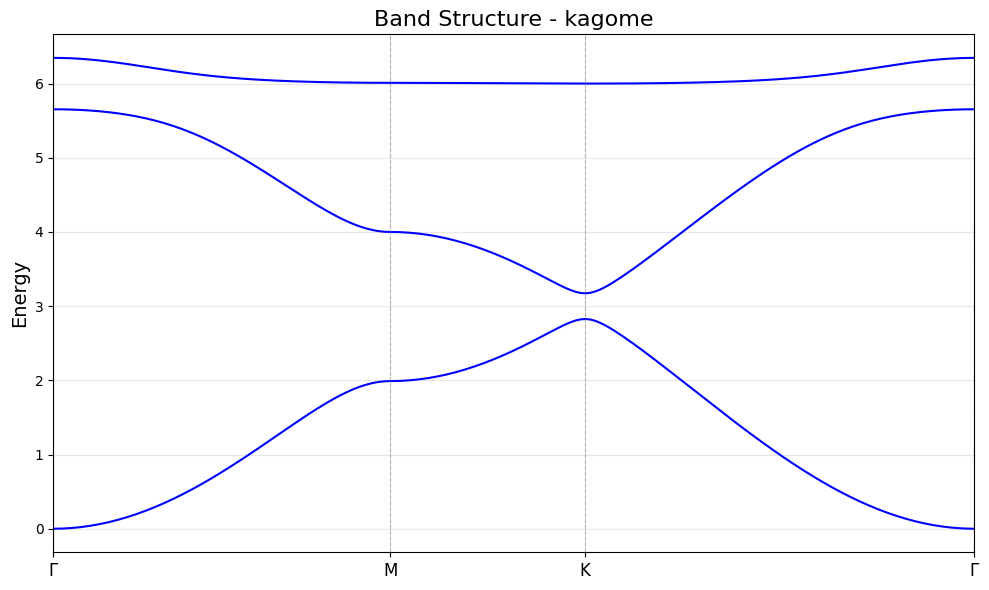

In [13]:
fig = bands.plot(
    title=f"Band Structure - {'kagome'}",
    color='blue',
    linewidth=1.5,
    figsize=(10, 6),
    show=True,  # Display inline in notebook
)

In [14]:
bands3d = BandStructure3D(
        hamiltonian=hamil,
        colpa=colpa,
        bz_type='hexagonal',
        system_name='kagome',
    )

bands3d.compute_on_mesh(
        n_kx=200,
        n_ky=200,
        detect_degeneracies=True,
        n_cores=10
    )

fig3d = bands3d.plot(
        mode='overlay',
        color_by='band',
        opacity=0.7,
        show=True,  # Opens in browser
    )

In [ ]:
width = 20
flat_flat = build_flat_flat(width)

In [ ]:
slab = InputReader('kagome_flat_flat.csv')

In [ ]:
parsed = Parser(slab.translation_vectors, slab.spin_data, slab.interaction_data, slab.parameters)
parsed.parse()

In [ ]:
flat = SpinSystem(parsed.translation_vectors, parsed.spin_data, parsed.interaction_data, parsed.parameters)
flatham = Hamiltonian(flat)

n_cores = 10
pool = Parallel(n_jobs=n_cores)

In [ ]:
dir = flat.reciprocal_vectors[0]
ks = np.linspace(-1, 1, 1000)


def compute_at_single_k(k):
    H_k = flatham.compute_at_k(k)
    eigs, _ = colpa.diagonalize(H_k, k=k, return_full=True)
    return eigs





energies = np.empty((len(ks), 2*zigzag.lat.n_sublats))
amps = np.empty((len(ks), zigzag.lat.n_sublats, zigzag.lat.n_sublats))
eigvects = np.empty((len(ks), 2*zigzag.lat.n_sublats, 2*zigzag.lat.n_sublats), dtype='complex')

for i, j in enumerate(ks):
    k = j*dir # cut dir vector into len(ks)-1 pieces
    E, EV = zigzag.Bogoliubov_trafo(k[0], k[1], k[2])
    amp = zigzag.sublat_localization(EV)
    energies[i] = E
    amps[i] = amp
    eigvects[i] = EV

energies = energies[:, :len(energies[1]) // 2]

In [ ]:
layers = 5
loc = amps[:, :, -8:].sum(axis=-1) - amps[:, :, :8].sum(axis=-1)

tol = 1e-5 #zigzag.parameters['chempot']
degen_mask = np.zeros_like(energies, dtype=bool)

nk, nbands = energies.shape

for i in range(nk):
    e_on_k = energies[i, :]

    for j in range(nbands):
        if j > 0 and np.abs(e_on_k[j] - e_on_k[j-1]) < tol:
            degen_mask[i, j] = True
        if j < (nbands-1) and np.abs(e_on_k[j] - e_on_k[j+1]) < tol:
            degen_mask[i, j] = True

loc[degen_mask] = 0

In [ ]:
for i in range(nbands):
    bandplot = plt.scatter(ks, energies[:,i], marker = '.', c = loc[:, i], edgecolor='none', cmap = 'coolwarm', vmin = -1.0, vmax = 1.0, s = 10)

cbar = plt.colorbar(bandplot)
cbar.set_label('edge localization', fontsize = 12)
cbar.set_ticks([-1, 1])
cbar.set_ticklabels(['bottom', 'top'])
cbar.ax.yaxis.set_label_coords(1.5, 0.5)
cbar.ax.tick_params(labelsize = 9)

tick_positions = [0, 0.25, 0.5, 0.75, 1]
tick_labels = [r"$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"]
plt.xticks(tick_positions, tick_labels)
plt.xlabel(r'$k \, \, [a^{-1}]$', fontsize=12)
plt.ylabel(r'$\varepsilon(k) \, \, [\mathrm{meV}]$', fontsize=12)
plt.margins(x=0, y=0)
plt.ylim(0,6.5)
plt.show